In [1]:
import cv2 
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
cv2.__version__ # IMPORTANT details to record

'4.9.0'

# Recommendation QIP algorithm
 - The PCT was administered on paper, the paper was scanned, and then saved in the portable network graphics 
(png) format.

In [2]:
img = cv2.imread(f"dataset/samples/0ECFA35F-87BC-4189-8AF8-08DD8B834DD4_Week_168_Visit_PACC_-_Version_A_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/6B0D6B92-2DE3-42F1-8AF7-08DD8B834DD4_Week_168_Visit_PACC_-_Version_A_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/9D29816B-87DD-4769-2776-08DD6B7CB098_Week_72_Visit_PACC_-_Version_B_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/59D226E1-AA4E-4D07-69EE-08DD81123178_Week_72_Visit_PACC_-_Version_B_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/3958C7C5-417F-4D7A-24E6-08DD6B7CB098_Week_48_Visit_PACC_-_Version_A_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/48964A27-FA15-4688-6CE4-08DD81123178_Week_48_Visit_PACC_-_Version_A_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/D1BC9C9B-240A-4E64-7A50-08DDB2C4B1C7_Week_192_Visit_PACC_-_Version_B_MMSEdrawing_page1.png")
# img = cv2.imread(f"dataset/samples/D9B0BBA8-1F0A-49E2-8E42-08DD9CE9F263_Week_120_Visit_PACC_-_Version_B_MMSEdrawing_page1.png")


## Original Image

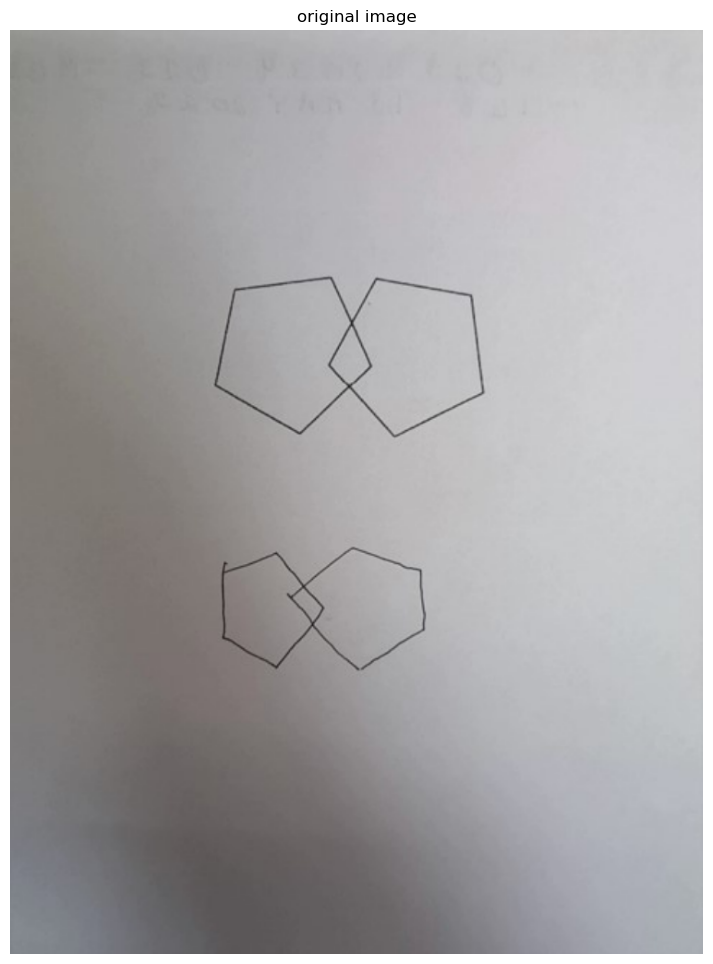

In [3]:
fig, axarr = plt.subplots(1,1, figsize=(12,12))
axarr.set_title('original image')
axarr.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.show()

## Canny Edge Detection (Primary Edge Detection)

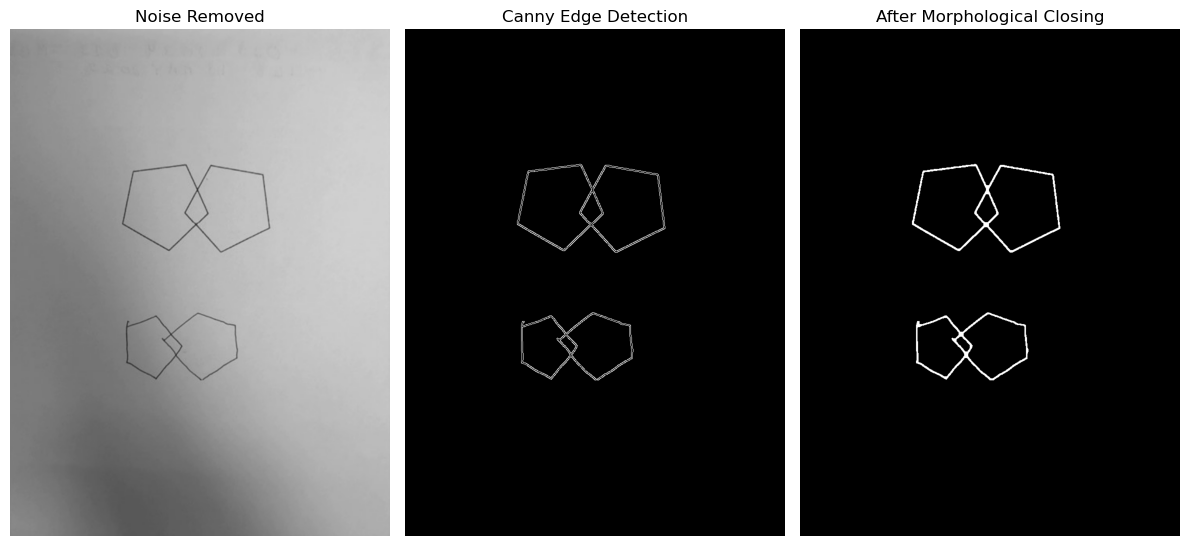

In [4]:
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise and detail
blurred = cv2.GaussianBlur(gray, (5, 5), 0.1)

# Perform Canny Edge Detection
edges = cv2.Canny(blurred, threshold1=100, threshold2=200)

# 1. Define the kernel (size 5x5 is common, but 3x3 or 7x7 might be better depending on line thickness)
kernel = np.ones((5, 5), np.uint8)

# 2. Apply Closing: Dilation followed by Erosion. 
# This fills small gaps and closes small holes in the edges.
cleaned_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# Plotting
fig, axarr = plt.subplots(1,3, figsize=(12, 12))

axarr[0].set_title('Noise Removed')  # Use set_title(), not title()
axarr[0].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axarr[0].axis('off')

axarr[1].set_title('Canny Edge Detection')  # Use set_title(), not title()
axarr[1].imshow(edges, cmap='gray')
axarr[1].axis('off')

axarr[2].set_title('After Morphological Closing')
axarr[2].imshow(cleaned_edges, cmap='gray')
axarr[2].axis('off')

plt.tight_layout()
plt.show()



## Tight Cropping to Focus Regions

Total contours found: 2


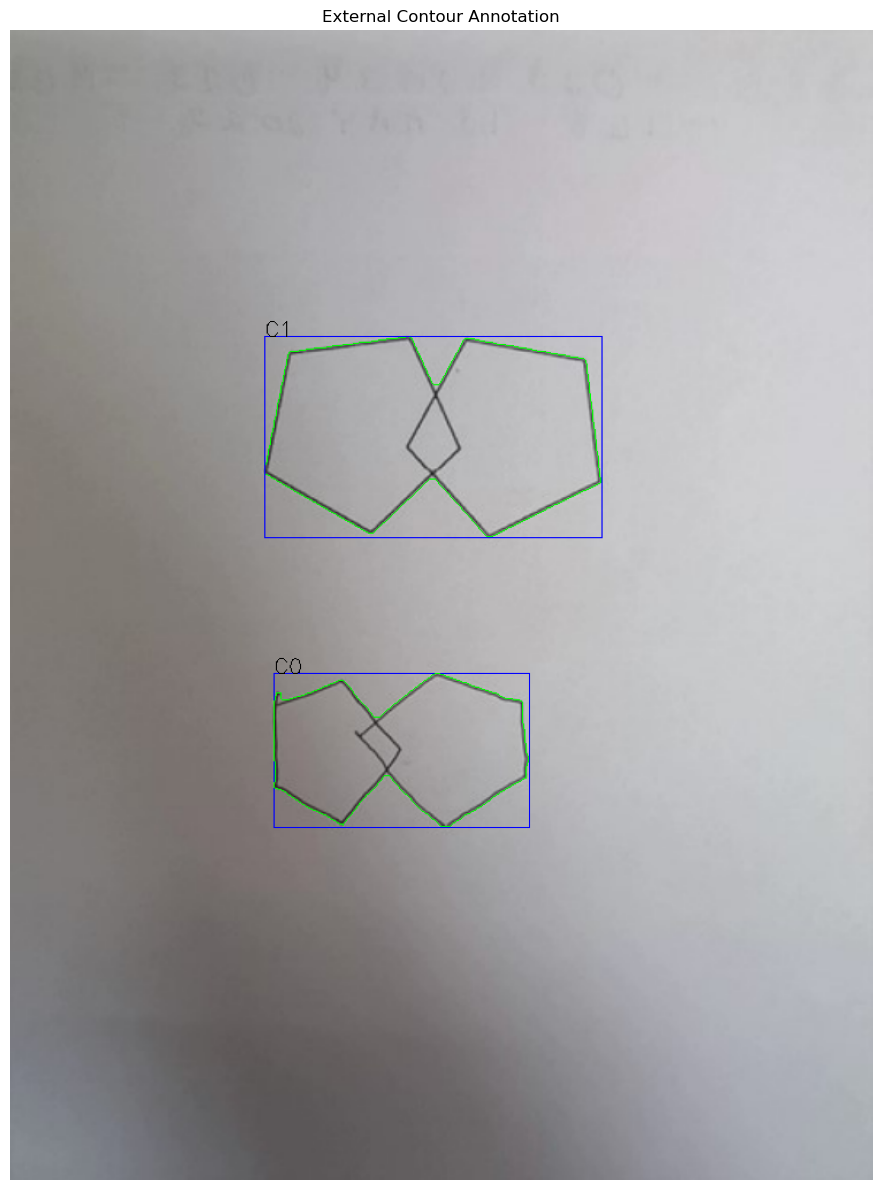

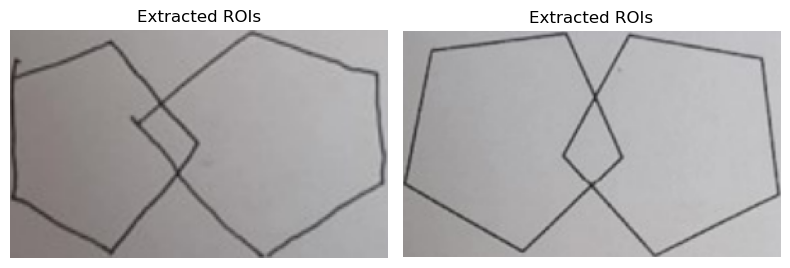

In [5]:
ann_img = img.copy()
contours, hierarchy = cv2.findContours(cleaned_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) # for nested contours
print(f"Total contours found: {len(contours)}")

roi_window = {f"C{i}": [] for i in range(len(contours))}
roi = {f"C{i}": np.ndarray for i in range(len(contours))} # dict for extracted roi imgs
for i, cnt in enumerate(contours):
    # area filtering of contours
    # shape filtering of contours (solidity)
    x,y,w,h = cv2.boundingRect(cnt)
    roi_window[f"C{i}"].append([x,y,w,h])
    cv2.drawContours(ann_img, contours, -1, (0, 255, 0), 1)
    cv2.rectangle(ann_img, (x,y), (x+w,y+h), (255,0,0), 1)
    cv2.putText(ann_img, f"C{i}", (x,y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)
    
# contour annotations on the original image's detected edges
fig, axarr = plt.subplots(1, 1, figsize=(12, 12))
axarr.set_title('External Contour Annotation') 
axarr.imshow(cv2.cvtColor(ann_img, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.tight_layout()
plt.show()

# crop to ROI windows (2 pairs of sub-images representing template and handdrawn figures)
num_roi = len(roi_window)
n_cols = min(3, num_roi)               # Max 3 columns
n_rows = (num_roi + n_cols - 1) // n_cols  # Ceiling division for rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()  # Flatten in case of single row/column
for idx, contour_id in enumerate(roi_window):
    x,y,w,h = roi_window[contour_id][0]
    roi_img = img[y:y+h, x:x+w]
    roi[contour_id] = roi_img
    # visualization
    axes[idx].set_title('Extracted ROIs') 
    axes[idx].imshow(cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB))
    axes[idx].axis('off')

# Hide any unused subplots
for ax in axes[num_roi:]:
    ax.axis('off')

plt.tight_layout()
plt.show()




## Secondary Canny Edge Detection on ROI Image

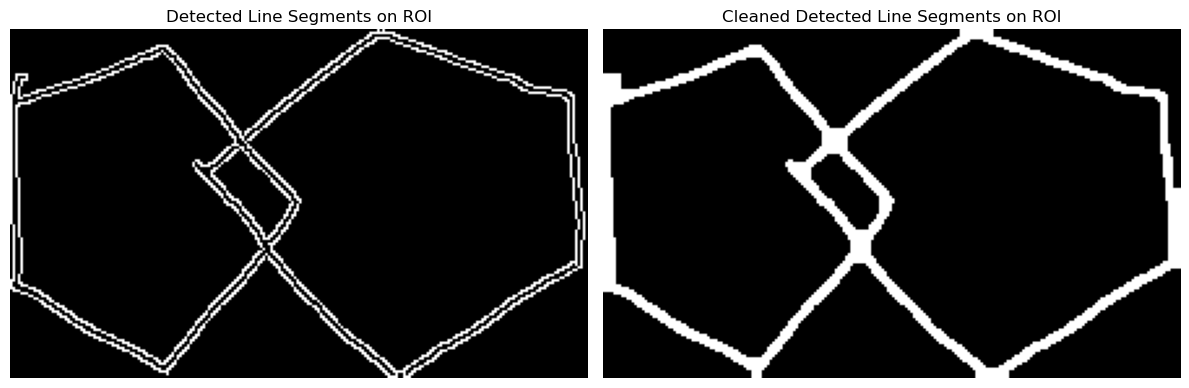

In [6]:
cnd_id = list(roi.keys())[0]
roi_img = roi[cnd_id]

# ---------------------------- CANNY EDGE DETECTION FLOW ---------------------
# Convert to grayscale
roi_gray = cv2.cvtColor(roi_img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise and detail
roi_blurred = cv2.GaussianBlur(roi_gray, (5, 5), 0.1)

# Perform Canny Edge Detection
roi_edges = cv2.Canny(roi_blurred, threshold1=100, threshold2=200)

# 1. Define the kernel (size 5x5 is common, but 3x3 or 7x7 might be better depending on line thickness)
kernel = np.ones((5, 5), np.uint8)

# 2. Apply Closing: Dilation followed by Erosion. 
# This fills small gaps and closes small holes in the edges.
roi_cleaned_edges = cv2.morphologyEx(roi_edges, cv2.MORPH_CLOSE, kernel)
# ----------------------------------------------------------------------------

fig, axarr = plt.subplots(1, 2, figsize=(12, 12))
axarr[0].set_title('Detected Line Segments on ROI') 
axarr[0].imshow(cv2.cvtColor(roi_edges, cv2.COLOR_BGR2RGB))
axarr[0].axis('off')

axarr[1].set_title('Cleaned Detected Line Segments on ROI') 
axarr[1].imshow(cv2.cvtColor(roi_cleaned_edges, cv2.COLOR_BGR2RGB))
axarr[1].axis('off')

plt.tight_layout()
plt.show()


## Houghline for straight line detection

In [7]:
def point_on_segment(x, y, xA, yA, xB, yB, eps):
    return (min(xA, xB) - eps <= x <= max(xA, xB) + eps and min(yA, yB) - eps <= y <= max(yA, yB) + eps) # check if the points inside the line segment

def get_intersection_point(line1, line2, method=0, parallel_threshold=1.0e-10, eps=1.0e-10):
    # 0-houghlineP and 1-houghlines
    if method == 0:
        rho1, theta1 = line1[0]
        rho2, theta2 = line2[0]

        A = np.array([
            [np.cos(theta1), np.sin(theta1)],
            [np.cos(theta2), np.sin(theta2)]
        ])
        b = np.array([rho1, rho2])

        if np.linalg.det(A) > parallel_threshold:
            inter_x, inter_y = np.linalg.solve(A, b) 
            return float(inter_x), float(inter_y)
        else:
            return None
    else:
        x1,y1,x2,y2 = line1[0]
        x3,y3,x4,y4 = line2[0]
        # cramers rule to check for parallelity
        a1 = (y2-y1)
        b1 = (x1-x2)
        c1 = (a1*x1 + b1*y1)

        a2 = (y4-y3)
        b2 = (x4-x3)
        c2 =  a2*x3 + b2*y3

        # use this or use the numpy vectorization to solve and check for parallelity (like shown above)
        det = a1*b2-a2*b1 # det(A) == > AX = C
        # Use parallel_threshold instead of exact zero
        if np.abs(det) > parallel_threshold:
            Dx = c1*b2 - c2*b1
            Dy = a1*c2 - a2*c1
            inter_x = Dx / det
            inter_y = Dy / det
            on1 = point_on_segment(inter_x, inter_y, x1, y1, x2, y2, eps)
            on2 = point_on_segment(inter_x, inter_y, x3, y3, x4, y4, eps)

            if on1 and on2:
                return float(inter_x), float(inter_y)
        else:
            return None


In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cv2
import numpy as np

ann_img = img.copy()
# Hougline Transformation
lines = cv2.HoughLines(cleaned_edges, 1, np.pi / 180, 63, None, 0, 0) # for cleaned edges use threshold of 63, for edges(raw): 48
filtered_lines = []

def tune_houghlines(rho_thresh=50, theta_thresh_deg=5):
    theta_thresh = np.deg2rad(theta_thresh_deg)  # convert degrees to radians
    ann_img_copy = ann_img.copy()  # use your existing ann_img

    if lines is None:
        print("No lines detected")
        return

    similar_lines = {i: [] for i in range(len(lines))}
    for i in range(len(lines)):
        rho_i, theta_i = lines[i][0]
        for j in range(i + 1, len(lines)):
            rho_j, theta_j = lines[j][0]
            if abs(rho_i - rho_j) < rho_thresh and abs(theta_i - theta_j) < theta_thresh:
                similar_lines[i].append(j)

    indices = list(range(len(lines)))
    indices.sort(key=lambda x: similar_lines[x])
    line_flags = [True] * len(lines)
    for i in range(len(lines) - 1):
        if not line_flags[indices[i]]:
            continue
        for j in range(i + 1, len(lines)):
            if not line_flags[indices[j]]:
                continue
            rho_i, theta_i = lines[indices[i]][0]
            rho_j, theta_j = lines[indices[j]][0]
            if abs(rho_i - rho_j) < rho_thresh and abs(theta_i - theta_j) < theta_thresh:
                line_flags[indices[j]] = False

    filtered_lines = []
    for i in range(len(lines)): # filtering
        if line_flags[i]:
            filtered_lines.append(lines[i])

    if filtered_lines is not None:
        for idx, line in enumerate(filtered_lines):
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))

            cv2.line(ann_img_copy, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.circle(ann_img_copy, (x1, y1), 6, (0, 255, 0), -1)
            cv2.circle(ann_img_copy, (x2, y2), 6, (255, 0, 0), -1)

    clear_output(wait=True)
    plt.figure(figsize=(12, 12))
    plt.title(f"Detected Lines: rho_thresh={rho_thresh}, theta_thresh={theta_thresh_deg}°")
    plt.imshow(cv2.cvtColor(ann_img_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


# Sliders for dynamic tuning
rho_slider = widgets.IntSlider(min=1, max=200, step=1, value=50, description='Rho Threshold')
theta_slider = widgets.IntSlider(min=1, max=10, step=1, value=5, description='Theta Threshold (deg)')

widgets.interact(tune_houghlines, rho_thresh=rho_slider, theta_thresh_deg=theta_slider)


interactive(children=(IntSlider(value=50, description='Rho Threshold', max=200, min=1), IntSlider(value=5, des…

<function __main__.tune_houghlines(rho_thresh=50, theta_thresh_deg=5)>

Number of Lines Detected: 210
{0: [1, 7, 8, 53, 115, 135, 146, 203], 1: [7, 8, 53, 115, 135, 146, 203], 2: [3, 10, 28, 66, 98], 3: [10, 28, 36], 4: [5, 6, 11, 44, 93, 156, 182, 196], 5: [6, 11, 12, 44, 61], 6: [11, 12, 44, 61, 90, 183], 7: [8, 68, 105, 115, 135, 146, 203], 8: [53, 105, 115, 135, 146, 203], 9: [15, 23, 29, 51, 70, 125], 10: [36], 11: [44, 93, 156, 182], 12: [61, 90, 117, 183], 13: [14, 16, 24, 54, 72, 162], 14: [16, 24, 54, 108], 15: [23, 51, 125, 187], 16: [24, 54, 108, 144, 163], 17: [33, 62, 168], 18: [22, 27, 104], 19: [31, 39, 43, 52, 154], 20: [25, 32, 45, 50, 107], 21: [26, 35, 48, 49, 123, 124, 139, 164, 186, 208, 209], 22: [27, 41, 104], 23: [29, 70, 169], 24: [72, 162], 25: [32, 45, 50, 107], 26: [35, 48, 49, 122, 123, 164, 186, 208, 209], 27: [41, 73], 28: [66, 98], 29: [70, 169], 30: [34, 37, 38, 42, 55, 106], 31: [39, 43, 52, 109, 149], 32: [45, 80, 141], 33: [62], 34: [37, 38, 42, 55, 147], 35: [48, 49, 123, 124, 129, 139, 164, 186, 208, 209], 36: [201], 3

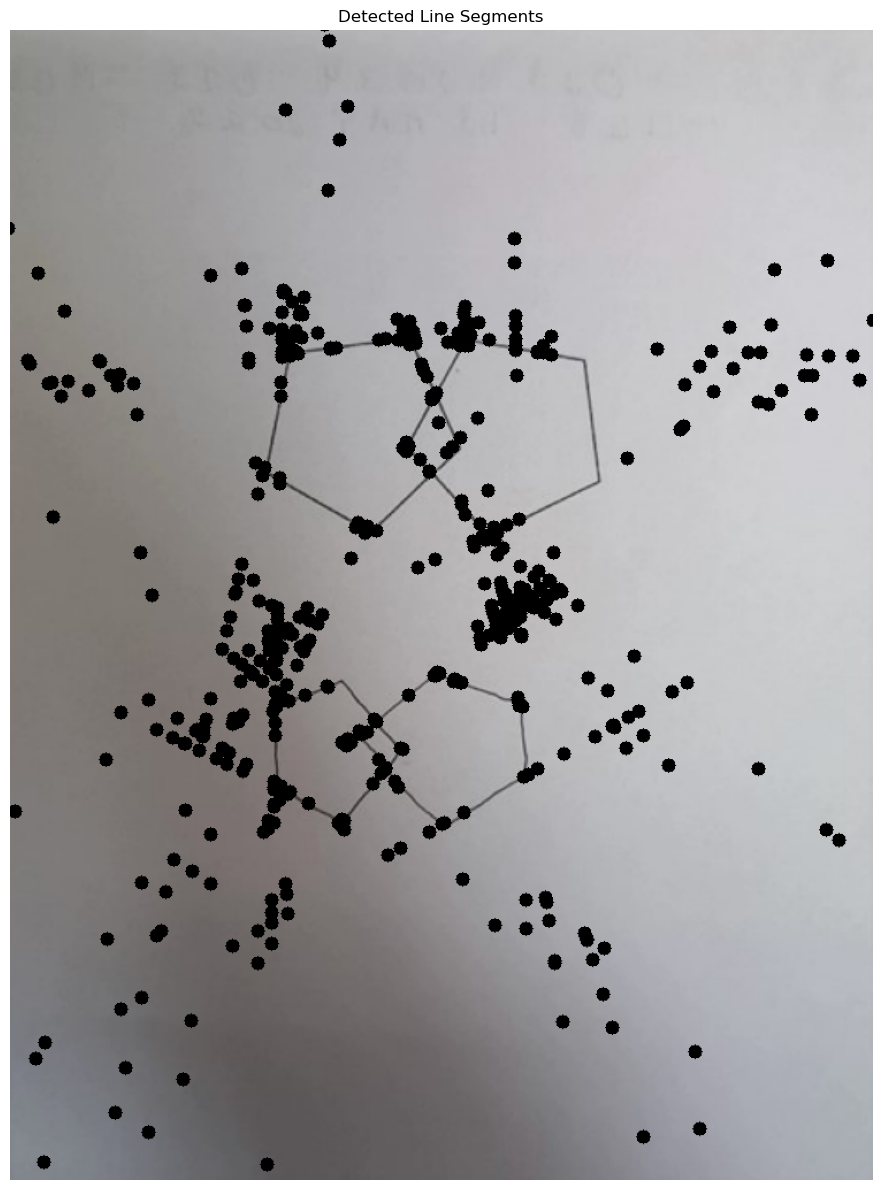

In [9]:
# Standard Houghline function usage

# img # bgr
# gray # gray
# edges # raw canny edges
# cleaned_edges # cleaned detected canny edges
ann_img = img.copy()

# Hougline Transformation
lines = cv2.HoughLines(cleaned_edges, 1, np.pi / 180, 63, None, 0, 0) # for cleaned edges use threshold of 63, for edges(raw): 48
filtered_lines = []

rho_threshold = 136       # distance in pixels
theta_threshold = np.deg2rad(3) #  angle in rad converted from deg

if lines is not None:
    print(f"Number of Lines Detected: {len(lines)}")
    similar_lines = {i : [] for i in range(len(lines))} # index of the similar lines
    
    # # the sudoku filter
    for i in range(len(lines)):
        rho_i = lines[i][0][0]
        theta_i = lines[i][0][1]
        for j in range(i+1, len(lines)): # logic flaw need to fix (if i similar to j then j similar to i too) and ignore comparison of same line segments (i==j)
            rho_j = lines[j][0][0]
            theta_j = lines[j][0][1]

            if (np.abs(rho_i-rho_j) < rho_threshold) and (np.abs(theta_i-theta_j) < theta_threshold):
                similar_lines[i].append(j)
    
    print(similar_lines)

    # --------------------------- merging algorithm -------------------------------------
    # ordering the INDECES of the lines by how many are similar to them
    indices = [i for i in range(len(lines))]# array of indices of the lines
    indices.sort(key=lambda x: similar_lines[x])
    # line flags is the base for the filtering
    line_flags = len(lines)*[True]
    for i in range(len(lines) - 1):
        if not line_flags[indices[i]]: # if we already disregarded the ith element in the ordered list then we don't care (we will not delete anything based on it and we will never reconsider using this line again)
            continue

        for j in range(i + 1, len(lines)): # we are only considering those elements that had less similar line
            if not line_flags[indices[j]]: # and only if we have not disregarded them already
                continue

            rho_i,theta_i = lines[indices[i]][0]
            rho_j,theta_j = lines[indices[j]][0]
            if abs(rho_i - rho_j) < rho_threshold and abs(theta_i - theta_j) < theta_threshold:
                line_flags[indices[j]] = False # if it is similar and have not been disregarded yet then drop it now

    filtered_lines = []
    for i in range(len(lines)): # filtering
        if line_flags[i]:
            filtered_lines.append(lines[i])

    print('Number of filtered lines:', len(filtered_lines))
    # -------------------------------------------------------------------------------------

intersection_points = []
if filtered_lines is not None:
    for line in filtered_lines:
        rho,theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        # cv2.line(ann_img,(x1,y1),(x2,y2),(0,0,255),2)
        # # Annotate endpoints
        # cv2.circle(ann_img, (x1, y1), 6, (0, 255, 0), -1)  # green circle at x1,y1
        # cv2.circle(ann_img, (x2, y2), 6, (255, 0, 0), -1)  # blue circle at x2,y2

    # finding and annotating intersection points
    for i in range(len(filtered_lines)):
        for j in range(i+1, len(filtered_lines)):
            ref_line = filtered_lines[i]
            point = get_intersection_point(line1=ref_line, line2=filtered_lines[j], method=0, parallel_threshold=1e-10)
            if point is not None:
                xi, yi = int(point[0]), int(point[1])
                intersection_points.append((xi,yi))
                cv2.circle(ann_img, (xi, yi), 6, (0, 0, 0), -1)
        

if intersection_points is not None:
    print(f"Number of intersection points: {len(intersection_points)}")

# --- Display the Annotated Image ---
fig, axarr = plt.subplots(1, 1, figsize=(12, 12))
axarr.set_title('Detected Line Segments') 
axarr.imshow(cv2.cvtColor(ann_img, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.tight_layout()
plt.show()


C0
Found 37 line segments.
Number of clusters unravelled: 2


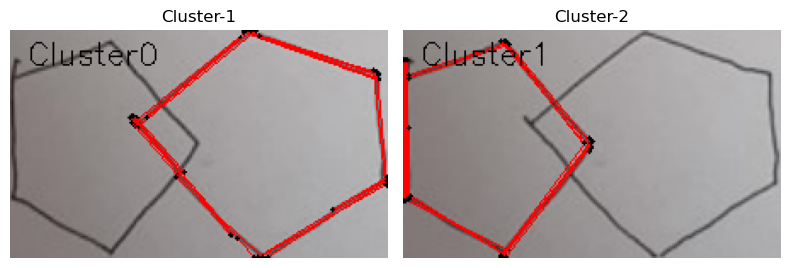

In [10]:
# Probability Based HoughLine Detection to get line segments straight away

# 4. Hough Line Transform (Probabilistic Hough Line Transform - HoughLinesP)
# HoughLinesP is generally better for finding the endpoints of line segments.
# Parameters:
# edges: Output of the Canny detector.
# 1: rho accuracy (distance resolution in pixels)
# np.pi/180: theta accuracy (angular resolution in radians)
# 50: threshold (minimum number of intersections to 'detect' a line)
# 10: minLineLength (minimum line length. Shorter lines are rejected)
# 5: maxLineGap (maximum allowed gap between line segments to treat them as a single line)

print(cnd_id)
ann_roi = roi_img.copy()
lines = cv2.HoughLinesP(roi_cleaned_edges, 1, np.pi / 180, 34, minLineLength=6, maxLineGap=21)

# 5. Draw the detected lines on the original image
if lines is not None:
    for line in lines:
        # line is an array [[x1, y1, x2, y2]]
        x1, y1, x2, y2 = line[0]
        # Draw the line (color: BGR (0, 255, 0) = Green, thickness: 2)
        cv2.line(ann_roi, (x1, y1), (x2, y2), (0, 255, 0), 2)
    print(f"Found {len(lines)} line segments.")

    intersection_points = []
    # finding and annotating intersection points
    for i in range(len(lines)):
        for j in range(i+1, len(lines)):
            point = get_intersection_point(line1=lines[i], line2=lines[j], method=1, parallel_threshold=1e-6, eps=3.0)
            if point is not None:
                xi, yi = int(point[0]), int(point[1])
                cv2.circle(ann_roi, (xi, yi), 6, (0, 0, 0), -1)
else:
    print("No line segments were found.")


n = len(lines)
distance_threshold = 5.0 # [pixel units] for a secondary closeness check for line segment connectivity and intersection
# creating connectivity matrix using the detected line segments
connectivity_matrix = np.full(shape=(n,n), fill_value=False)
for i in range(len(lines)):
    for j in range(i+1, len(lines)):
        x1,y1,x2,y2 = lines[i][0]
        x3,y3,x4,y4 = lines[j][0]
        connected = False
        
        # check connection again if not connected
        if not connected:
            endpoints_i = [(x1,y1), (x2,y2)]
            endpoints_j = [(x3,y3), (x4,y4)]
            for p in endpoints_i:
                for q in endpoints_j:
                    if np.linalg.norm(np.array(p)-np.array(q)) < distance_threshold:
                        connected = True
                        break
                if connected:
                    break

        if connected:
            connectivity_matrix[i, j] = connectivity_matrix[j,i] = True

# unravelling the intersecting pentagon figures/clusters (need to separate out the intersecting pentagons first)
if connectivity_matrix is not None:
    # the Search algorithm to find the unravelled clusters (BFS) --> any deterministic non-heuristic search algo would do good make sure to be optimal though
    n = connectivity_matrix.shape[0]
    visited_nodes = np.zeros(shape=n, dtype=bool)# keep track of visited nodes to end the search
    clusters = []
    # index of the line specifies the node id in the graph
    for i in range(len(lines)):
        if not visited_nodes[i]:
            queue = deque([i]) # queue[list]
            cluster = []
            while queue: # while is not empty
                current_node = queue.popleft()
                # print(f"current line node: {current_node}")
                visited_nodes[current_node]=True
                cluster.append(current_node)
                # get neighbours
                neighbours = np.where(connectivity_matrix[current_node]==1)[0]
                for neigh_node in neighbours:
                    if not visited_nodes[neigh_node]:
                        queue.append(neigh_node)
                
            clusters.append(cluster)
    

print(f"Number of clusters unravelled: {len(clusters)}")
H,W = img.shape[:2]
h,w = roi_img.shape[:2]
roi_bounds = roi_window[cnd_id]
x,y,w,h = roi_bounds[0]


if lines is not None and len(clusters)>0:
    n_clusters = len(clusters)
    n_cols = min(3, n_clusters)               # Max 3 columns
    n_rows = (n_clusters + n_cols - 1) // n_cols  # Ceiling division for rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()  # Flatten in case of single row/column

    for idx, cluster in enumerate(clusters):
        ann_cpy = roi_img.copy()
        for line_idx in cluster:
            # line is an array [[x1, y1, x2, y2]]
            x1, y1, x2, y2 = lines[line_idx][0]
            # x1,y1,x2,y2 = x+x1, y+y1, x+x2, y+y2 # roi frame to og frame
            cv2.line(ann_cpy, (x1, y1), (x2, y2), (0, 0, 255), 1)
            cv2.circle(ann_cpy, (x1, y1), 1, (0, 0, 0), -1) # segment point-1
            cv2.circle(ann_cpy, (x2, y2), 1, (0, 0, 0), -1) # segment point-2
            cv2.putText(ann_cpy, f"Cluster{idx}", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)
        
        axes[idx].imshow(cv2.cvtColor(ann_cpy, cv2.COLOR_BGR2RGB))
        axes[idx].set_title(f'Cluster-{idx+1}', fontsize=12)
        axes[idx].axis('off')

    # Hide any unused subplots
    for ax in axes[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Contours From Cluster points (Test Program)

Recalling the number of raw line segments detected: 37
Number of clusters unravelled: 2
cluster0: [(72, 54), (139, 0), (70, 51), (143, 133), (137, 0), (216, 28), (75, 56), (144, 0), (73, 56), (135, 4), (138, 0), (216, 25), (74, 51), (102, 83), (71, 50), (130, 120), (72, 50), (133, 122), (137, 1), (216, 29), (71, 54), (129, 120), (80, 51), (141, 0), (146, 133), (221, 90), (145, 133), (221, 87), (74, 51), (102, 83), (71, 50), (130, 120), (72, 50), (133, 122), (71, 54), (129, 120), (73, 56), (135, 4), (138, 0), (216, 25), (215, 24), (221, 91), (137, 1), (216, 29), (146, 3), (216, 26), (80, 51), (141, 0), (73, 56), (135, 4), (71, 54), (129, 120), (146, 3), (216, 26), (80, 51), (141, 0), (137, 1), (216, 29), (71, 54), (129, 120), (213, 23), (220, 90), (215, 24), (221, 91), (137, 1), (216, 29), (146, 3), (216, 26), (80, 51), (141, 0), (71, 50), (130, 120), (72, 50), (133, 122), (71, 54), (129, 120), (72, 50), (133, 122), (71, 54), (129, 120), (71, 54), (129, 120), (146, 3), (216, 26), (80, 5

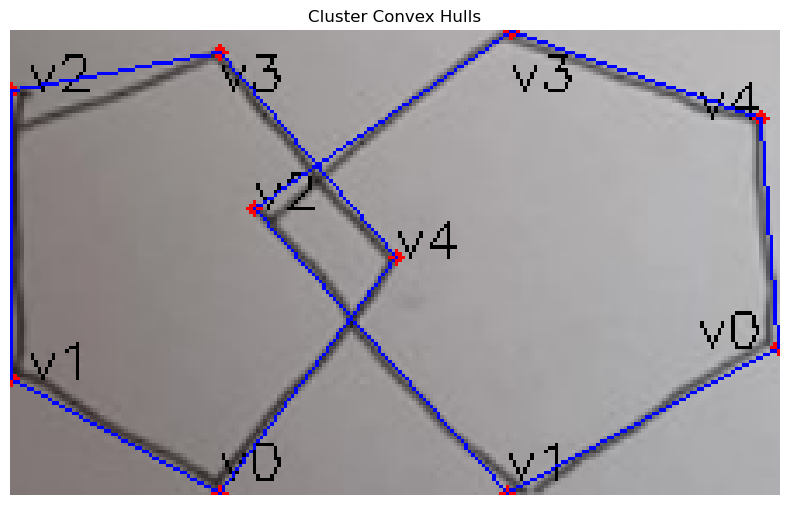

In [11]:

ann_roi = roi_img.copy()

# ------ PARAMETERS ----------
EPSILON_FACTOR = 0.02
# ----------------------------

polygon_info  = {f"cluster{i}": {} for i in range(len(clusters))} # free dictionary format

if clusters and lines is not None:
    print(f"Recalling the number of raw line segments detected: {len(lines)}")
    print(f"Number of clusters unravelled: {len(clusters)}")
    # clusters to contours (same algo as in the qip algo module)
    cluster_info = {f"cluster{i}": list for i in range(len(clusters))}
    for idx, cluster in enumerate(clusters):
        collected_points = []
        for line_idx in cluster:
            x1,y1,x2,y2 = lines[line_idx][0]
            collected_points.extend([(x1,y1), (x2,y2)])

        cluster_info[f"cluster{idx}"] = collected_points


    # cluster info
    for key in cluster_info:
        print(f"{key}: {cluster_info[key]}")

    # hull and poly approximation
    for key in cluster_info:
        seg_points = cluster_info[key]
        hull = cv2.convexHull(np.array(seg_points), returnPoints=True)
        # hull to poly approximation
        epsilon = EPSILON_FACTOR*cv2.arcLength(hull, True)
        approx_poly = cv2.approxPolyDP(hull, epsilon, True)
        # get image bounds
        h, w = ann_roi.shape[:2]
        margin = 5  # small padding to avoid edge overlap
        vertices = []
        for i, vertex in enumerate(approx_poly):
            vx, vy = vertex[0]
            vertices.append((vx,vy))
            label = f"v{i}"
            # measure text size
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            # ensure text is inside image bounds
            tx = np.clip(vx, margin, w - text_w - margin)
            ty = np.clip(vy, text_h + margin, h - margin)
            cv2.circle(ann_roi, (vx, vy), 2, (0, 0, 255), -1) # vertex points
            cv2.putText(ann_roi, label, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

        polygon_info[key] = {
            "cluster_id": key,
            "vertices": vertices,
            "seg_points": seg_points,    
        }
        # cv2.drawContours(ann_roi, [hull], -1, (0, 255, 0), 1) (for sanity check)
        # approx poly curve
        cv2.drawContours(ann_roi, [approx_poly], -1, (255, 0, 0), 1)

# Plotting
fig, axarr = plt.subplots(1,1, figsize=(8, 10))
axarr.set_title('Cluster Convex Hulls')  # Use set_title(), not title()
axarr.imshow(cv2.cvtColor(ann_roi, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.tight_layout()
plt.show()



{'cluster0': {'cluster_id': 'cluster0', 'vertices': [(221, 91), (143, 133), (70, 51), (144, 0), (216, 25)], 'seg_points': [(72, 54), (139, 0), (70, 51), (143, 133), (137, 0), (216, 28), (75, 56), (144, 0), (73, 56), (135, 4), (138, 0), (216, 25), (74, 51), (102, 83), (71, 50), (130, 120), (72, 50), (133, 122), (137, 1), (216, 29), (71, 54), (129, 120), (80, 51), (141, 0), (146, 133), (221, 90), (145, 133), (221, 87), (74, 51), (102, 83), (71, 50), (130, 120), (72, 50), (133, 122), (71, 54), (129, 120), (73, 56), (135, 4), (138, 0), (216, 25), (215, 24), (221, 91), (137, 1), (216, 29), (146, 3), (216, 26), (80, 51), (141, 0), (73, 56), (135, 4), (71, 54), (129, 120), (146, 3), (216, 26), (80, 51), (141, 0), (137, 1), (216, 29), (71, 54), (129, 120), (213, 23), (220, 90), (215, 24), (221, 91), (137, 1), (216, 29), (146, 3), (216, 26), (80, 51), (141, 0), (71, 50), (130, 120), (72, 50), (133, 122), (71, 54), (129, 120), (72, 50), (133, 122), (71, 54), (129, 120), (71, 54), (129, 120), (14

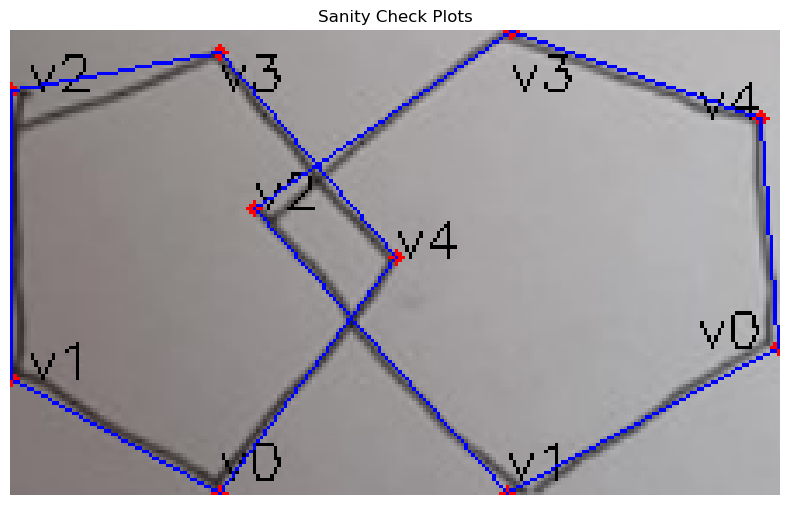

In [12]:



ann_roi = roi_img.copy()
print(polygon_info)
for cluster in polygon_info:
    clu_id = polygon_info[cluster]['cluster_id']
    print(f"Analysing cluster with id: {clu_id}")
    vertices = polygon_info[cluster]['vertices']
    seg_points = polygon_info[cluster]['seg_points']

    # point poly test
    for i, cluster_id in enumerate(polygon_info):
        ref_clu = polygon_info[cluster_id]['cluster_id']
        if ref_clu != clu_id:
            ref_seg = polygon_info[cluster_id]['seg_points']
            ref_hull = cv2.convexHull(np.array(ref_seg), returnPoints=True)
            for j, vertex in enumerate(vertices):
                vx, vy = map(float, vertex) 
                ret_dist = cv2.pointPolygonTest(ref_hull, (vx,vy), measureDist=False)
                if ret_dist == -1:
                    print(f"v-{j} is outside {ref_clu} cluster")
                elif ret_dist == 1:
                    print(f"v-{j} is inside {ref_clu} cluster")
                else:
                    print(f"v-{j} is on {ref_clu} cluster")

    for i in range(len(vertices)):
        vx, vy = vertices[i]
        label = f"v{i}"
        # measure text size
        (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        # ensure text is inside image bounds
        tx = np.clip(vx, margin, w - text_w - margin)
        ty = np.clip(vy, text_h + margin, h - margin)
        cv2.circle(ann_roi, (vx, vy), 2, (0, 0, 255), -1) # vertex points
        cv2.putText(ann_roi, label, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

    line_seg = []
    # line segments from vertices in cyclic pair parsing
    for i in range(len(vertices)):
        # if i == n-1:
        #     cv2.line(ann_roi, (vertices[n-1]), (vertices[0]), (255,0,0), 1)
        vx_i, vy_i = vertices[i-1] # at i==0 i-1 == -1 the final vertex
        vx_j,vy_j = vertices[i]
        line_seg.append([(vx_i, vy_i, vx_j, vy_j)])
        polygon_info[cluster]["line_segments"] = line_seg # FORMAT: x1y1,x2,y2

        cv2.line(ann_roi, (vx_i,vy_i), (vx_j,vy_j), (255,0,0),1)

print(f"\n")
for base_cluster in polygon_info:
    ref_id = polygon_info[base_cluster]['cluster_id']
    print(f"base cluster: {ref_id}")
    ref_segs = polygon_info[base_cluster]['line_segments']
    for cluster in polygon_info:
        clu_id = polygon_info[cluster]['cluster_id']
        if clu_id != ref_id:
            print(f"comparing with cluster: {clu_id}")
            line_segs = polygon_info[cluster]['line_segments']

            # check intersections between line segments between clusters
            for i in range(len(ref_segs)):
                for j in range(len(line_segs)):
                    line1 = ref_segs[i]
                    line2 = line_segs[j]
                    intersection = get_intersection_point(
                        line1=line1,
                        line2=line2,
                        method=1,
                        parallel_threshold=1e-6,
                        eps=1
                    )
                    if intersection:
                        print(f"{ref_id}-{line1} and {clu_id}-{line2} intersects")



# sanity check through plots
# Plotting
fig, axarr = plt.subplots(1,1, figsize=(8, 10))
axarr.set_title('Sanity Check Plots')
axarr.imshow(cv2.cvtColor(ann_roi, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def visualize_intersections(eps=1.0, parallel_threshold=1e-6):
    ann_roi = roi_img.copy()

    # --- Draw vertices and line segments ---
    for cluster in polygon_info:
        clu_id = polygon_info[cluster]['cluster_id']
        vertices = polygon_info[cluster]['vertices']

        line_seg = []
        for i in range(len(vertices)):
            vx_i, vy_i = vertices[i-1]
            vx_j, vy_j = vertices[i]
            line_seg.append((vx_i, vy_i, vx_j, vy_j))
            cv2.line(ann_roi, (vx_i, vy_i), (vx_j, vy_j), (255,0,0),1)

            # draw vertex
            cv2.circle(ann_roi, (vx_j, vy_j), 2, (0,0,255), -1)
            label = f"v{i}"
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            tx = np.clip(vx_j, margin, w - text_w - margin)
            ty = np.clip(vy_j, text_h + margin, h - margin)
            cv2.putText(ann_roi, label, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0),1)

        polygon_info[cluster]["line_segments"] = line_seg

    # --- Check intersections ---
    cluster_ids = list(polygon_info.keys())
    for i, base_cluster in enumerate(cluster_ids):
        ref_segs = polygon_info[base_cluster]["line_segments"]
        for cluster in cluster_ids[i+1:]:
            line_segs = polygon_info[cluster]["line_segments"]
            for line1 in ref_segs:
                for line2 in line_segs:
                    inter = get_intersection_point([line1], [line2], method=1, parallel_threshold=parallel_threshold, eps=eps)
                    if inter:
                        ix, iy = map(int, inter)
                        cv2.circle(ann_roi, (ix, iy), 4, (0,255,255), -1)  # mark intersection

    # --- Display ---
    fig, ax = plt.subplots(figsize=(8,10))
    ax.set_title(f"Intersections | eps={eps}, parallel_threshold={parallel_threshold}")
    ax.imshow(cv2.cvtColor(ann_roi, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    plt.show()

# --- Tuner sliders ---
interact(
    visualize_intersections,
    eps=FloatSlider(min=0.1, max=100, step=0.1, value=1.0),
    parallel_threshold=FloatSlider(min=1e-8, max=1e-4, step=1e-8, value=1e-6)
)

interactive(children=(FloatSlider(value=1.0, description='eps', min=0.1), FloatSlider(value=1e-06, description…

<function __main__.visualize_intersections(eps=1.0, parallel_threshold=1e-06)>

## Scoring/Evaluation Params 

## Checking the Accuracy of Canny Edge with Required Contours It Generates

Total contours found: 8
(550, 375)
-38.47076812334269
(550, 375)
-38.47076812334269


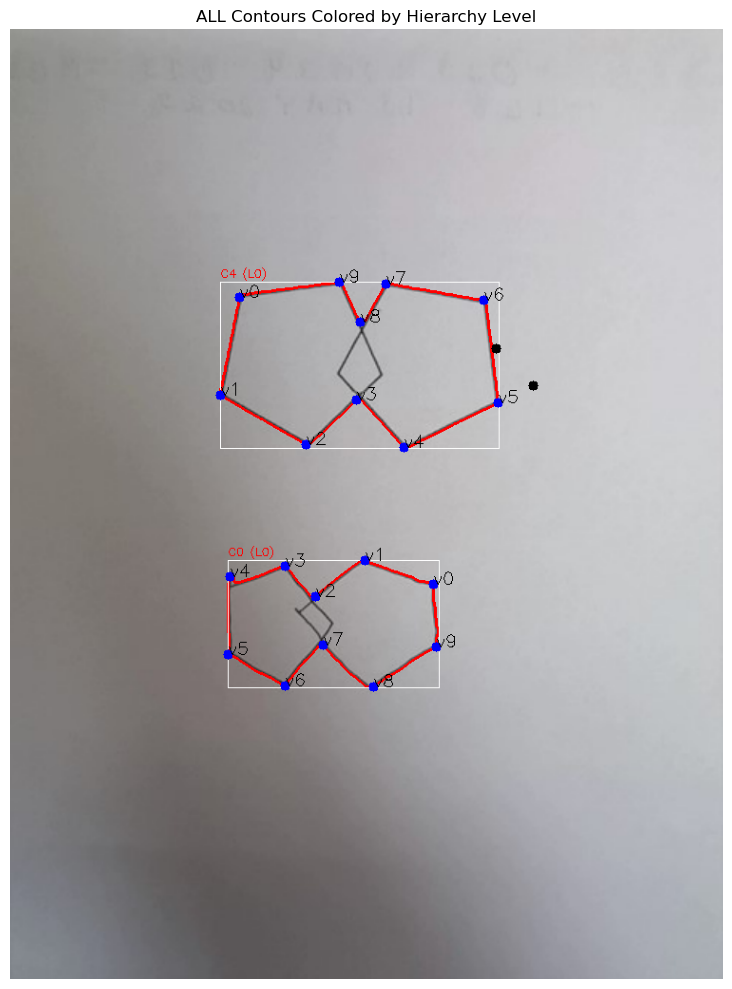

In [13]:
ann_img = img.copy()
contours, hierarchy = cv2.findContours(cleaned_edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE) # for nested contours

print(f"Total contours found: {len(contours)}")

# --- Process and Draw Contours by Hierarchy Level (All Contours) ---
if hierarchy is not None:
    hierarchy_array = hierarchy[0]

    for i, contour in enumerate(contours):
        cnt_area = cv2.contourArea(contour)
        if cnt_area < 5000:
            continue
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = float(cnt_area)/hull_area
        if solidity < 0.75:
            continue
        
        # # --- Hierarchy Level Detection ---
        level = 0
        parent_index = hierarchy_array[i][3]
        
        # # Traverse up the hierarchy tree to find the depth (level)
        while parent_index != -1: # until the contour has no parent
            level += 1
            parent_index = hierarchy_array[parent_index][3]

        # filtering based on contour level
        if level != 0:
            continue

        # --- Draw Contour and Bounding Box ---
        # Draw contour border
        cv2.drawContours(ann_img, contour, -1, (0,0,255), 2) # Use thinner line (1) for tiny contours
        # Draw bounding box (White)
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(ann_img, (x, y), (x + w, y + h), (255, 255, 255), 1)

        # polyDP approximation
        epsilon = 0.02*cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True) # got the approx polygon
        for j, vertices in enumerate(approx):
            vx, vy = vertices[0]
            center = (int(vx), int(vy))
            # Draw the vertex point
            label = f"v{j}"
            cv2.circle(ann_img, center, 5, (255, 0, 0), -1)
            cv2.putText(ann_img, f"{label}", (center), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)
        
        # Annotate with Contour ID and Level
        # Increase text size filter slightly to avoid overcrowding with tiny annotations
        if w > 10 and h > 10:
            label = f"C{i} (L{level})"
            cv2.putText(ann_img, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

        # point polygon test
        H,W = ann_img.shape[:2]
        p1 = (H//2+50, W//2)
        print(p1)
        cv2.circle(ann_img, p1, 5, (0, 0, 0), -1)
        ret = cv2.pointPolygonTest(cnt, p1, measureDist=True)
        print(ret)
        p2 = int(p1[0]+ret), int(p1[1]+ret)
        cv2.circle(ann_img, p2, 5, (0, 0, 0), -1)

# --- Display the Annotated Image ---
fig, axarr = plt.subplots(1, 1, figsize=(8, 10))
axarr.set_title('ALL Contours Colored by Hierarchy Level') 
axarr.imshow(cv2.cvtColor(ann_img, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.tight_layout()
plt.show()


## Match Shapes Usage for detecting template and handrawn figures

Contour 1 Match Score (Original vs. Polygon): 0.080839
Contour 2 Match Score (Original vs. Polygon): 0.003049


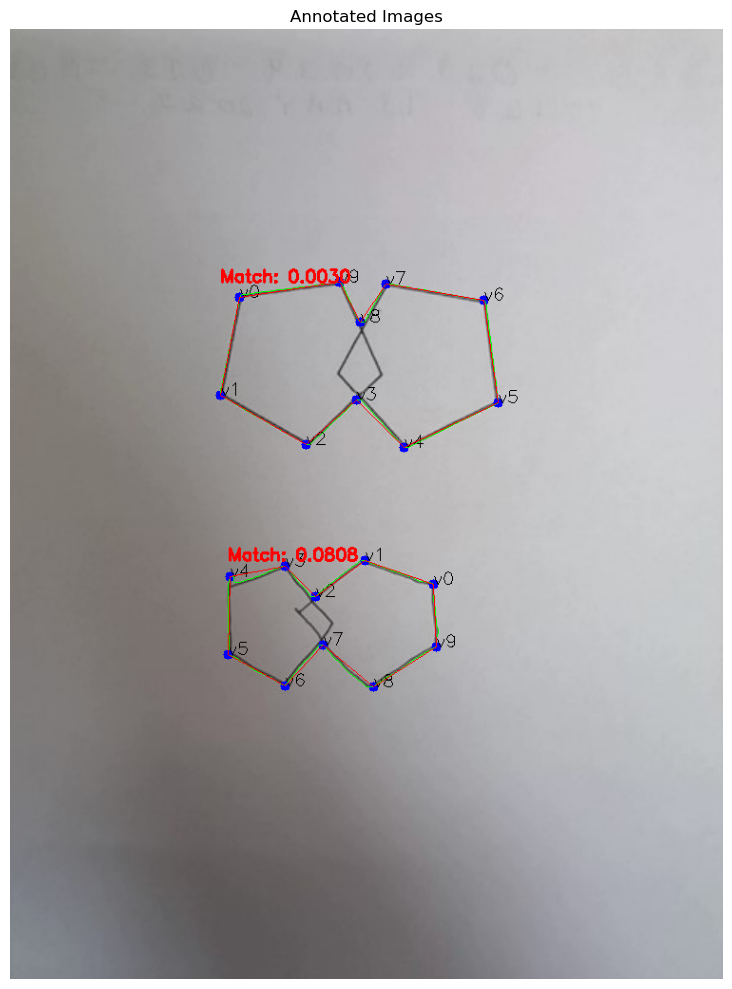

In [14]:

ann_img = img.copy()
contours, hierarchy = cv2.findContours(cleaned_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) # for nested contours

individual_masks = []
estimated_vertices = []
estimated_poly_cnts = []

# -- TUNABLE PARAMS ---
PERIMETER_FACTOR = 0.02
# ---------------------

filtered_contours = []
for i, contour in enumerate(contours):
    cnt_area = cv2.contourArea(contour)
    if cnt_area < 5000:
        continue
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = float(cnt_area)/hull_area
    if solidity < 0.75:
        continue

    # cv2.drawContours(ann_img, contours, -1, (0, 0, 255), 2)
    x, y, w, h = cv2.boundingRect(contour)
    # cv2.rectangle(ann_img, (x,y), (x+w, y+h), (255, 0, 0), 2)

    mask = np.zeros(gray.shape, np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)
    individual_masks.append(mask)
    filtered_contours.append(contour)

    # corner point detection    
    # extractong the contour corner/vertex points using polygon approximation
    epsilon = PERIMETER_FACTOR*cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True) # got the approx polygon
    estimated_poly_cnts.append(approx)
    for j, vertices in enumerate(approx):
        vx, vy = vertices[0]
        center = (int(vx), int(vy))
        estimated_vertices.append(center)
        # Draw the vertex point
        label = f"v{j}"
        cv2.circle(ann_img, center, 5, (255, 0, 0), -1)
        cv2.putText(ann_img, f"{label}", (center), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)


for i, (cnt1, cnt2) in enumerate(zip(filtered_contours,estimated_poly_cnts)):
    cv2.drawContours(ann_img, cnt1, -1, (0, 255, 0), 1)
    cv2.drawContours(ann_img, [cnt2], -1, (0, 0, 255), 1)
    match = cv2.matchShapes(cnt1, cnt2, cv2.CONTOURS_MATCH_I3, 0)
    print(f"Contour {i+1} Match Score (Original vs. Polygon): {match:.6f}")
    
    # Annotate the score on the image
    x, y, w, h = cv2.boundingRect(cnt1)
    
    cv2.putText(ann_img, f"Match: {match:.4f}", (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)


fig, axarr = plt.subplots(1,1, figsize=(8, 10))
axarr.set_title('Annotated Images')  # Use set_title(), not title()
axarr.imshow(cv2.cvtColor(ann_img, cv2.COLOR_BGR2RGB))
axarr.axis('off')
plt.tight_layout()
plt.show()

